# Projeto 01 - Superstore Sales Analysis

## Objetivo

Realizar uma análise exploratória dos dados de vendas da Superstore para identificar padrões de comportamento, oportunidades de crescimento e gerar recomendações que auxiliem a tomada de decisão da empresa.

In [13]:
import pandas as pd
import numpy as np

In [14]:
df = pd.read_csv(
    r'C:\Users\iago_\Projeto de vendas - Superstore Sales\superstore-sales-analysis\Dataset\Sample - Superstore.csv',
    encoding="latin1"
)

In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [17]:
new_columns = []
for colunas in df:
    colunas_strip = colunas.strip()
    colunas_lower = colunas_strip.lower()
    colunas_replace = colunas_lower.replace(' ', '_')
    new_columns.append(colunas_replace)


df.columns = new_columns

df.info()
#Os nomes das colunas foram padronizados para snake_case (minúsculas e underscore) visando melhorar a legibilidade e manter consistência ao longo da análise.


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   str    
 2   order_date     9994 non-null   str    
 3   ship_date      9994 non-null   str    
 4   ship_mode      9994 non-null   str    
 5   customer_id    9994 non-null   str    
 6   customer_name  9994 non-null   str    
 7   segment        9994 non-null   str    
 8   country        9994 non-null   str    
 9   city           9994 non-null   str    
 10  state          9994 non-null   str    
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   str    
 13  product_id     9994 non-null   str    
 14  category       9994 non-null   str    
 15  sub-category   9994 non-null   str    
 16  product_name   9994 non-null   str    
 17  sales          9994 non-null   float64
 18  quantity       9994

## Inspeção dos valores das colunas

Após padronizar os nomes das colunas, será realizada uma inspeção para verificar se os valores estão preenchidos de forma consistente e identificar possíveis inconsistências nos dados.

Para tornar essa etapa mais organizada e reutilizável, será criada uma função responsável por exibir informações importantes de cada coluna, como o tipo de dado, a quantidade de valores únicos, valores ausentes e a frequência de cada categoria, antes do início da análise exploratória dos dados (EDA).

## Column Value Inspection

After standardizing the column names, an inspection will be performed to verify that the values are consistently filled and to identify any potential data inconsistencies.

To make this step more organized and reusable, a function will be created to display key information about each column, such as its data type, the number of unique values, missing values, and the frequency of each category before starting the Exploratory Data Analysis (EDA).

In [18]:
def inspect_column(dataframe, column):
    print('=' * 50)
    print(f'Coluna: {column}')
    print(f'Tipo: {dataframe[column].dtype}')
    print(f'Valores únicos: {dataframe[column].nunique()}')
    print(f'Valores ausentes: {dataframe[column].isna().sum()}')
    print(dataframe[column].value_counts())

inspect_column(df, 'segment')
inspect_column(df, 'ship_mode')

Coluna: segment
Tipo: str
Valores únicos: 3
Valores ausentes: 0
segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64
Coluna: ship_mode
Tipo: str
Valores únicos: 4
Valores ausentes: 0
ship_mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


In [19]:
inspect_column(df, 'category')

Coluna: category
Tipo: str
Valores únicos: 3
Valores ausentes: 0
category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64


In [20]:
inspect_column(df, 'sub-category')

Coluna: sub-category
Tipo: str
Valores únicos: 17
Valores ausentes: 0
sub-category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64


In [21]:
inspect_column(df, 'region')
inspect_column(df, 'country')

Coluna: region
Tipo: str
Valores únicos: 4
Valores ausentes: 0
region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64
Coluna: country
Tipo: str
Valores únicos: 1
Valores ausentes: 0
country
United States    9994
Name: count, dtype: int64


In [22]:
inspect_column(df, 'state')

Coluna: state
Tipo: str
Valores únicos: 49
Valores ausentes: 0
state
California              2001
New York                1128
Texas                    985
Pennsylvania             587
Washington               506
Illinois                 492
Ohio                     469
Florida                  383
Michigan                 255
North Carolina           249
Arizona                  224
Virginia                 224
Georgia                  184
Tennessee                183
Colorado                 182
Indiana                  149
Kentucky                 139
Massachusetts            135
New Jersey               130
Oregon                   124
Wisconsin                110
Maryland                 105
Delaware                  96
Minnesota                 89
Connecticut               82
Missouri                  66
Oklahoma                  66
Alabama                   61
Arkansas                  60
Rhode Island              56
Utah                      53
Mississippi               53
Sou

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   str    
 2   order_date     9994 non-null   str    
 3   ship_date      9994 non-null   str    
 4   ship_mode      9994 non-null   str    
 5   customer_id    9994 non-null   str    
 6   customer_name  9994 non-null   str    
 7   segment        9994 non-null   str    
 8   country        9994 non-null   str    
 9   city           9994 non-null   str    
 10  state          9994 non-null   str    
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   str    
 13  product_id     9994 non-null   str    
 14  category       9994 non-null   str    
 15  sub-category   9994 non-null   str    
 16  product_name   9994 non-null   str    
 17  sales          9994 non-null   float64
 18  quantity       9994

In [24]:
date_columns = ['order_date', 'ship_date']

for column in date_columns:
    df[column] = pd.to_datetime(df[column])

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   str           
 2   order_date     9994 non-null   datetime64[us]
 3   ship_date      9994 non-null   datetime64[us]
 4   ship_mode      9994 non-null   str           
 5   customer_id    9994 non-null   str           
 6   customer_name  9994 non-null   str           
 7   segment        9994 non-null   str           
 8   country        9994 non-null   str           
 9   city           9994 non-null   str           
 10  state          9994 non-null   str           
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   str           
 13  product_id     9994 non-null   str           
 14  category       9994 non-null   str           
 15  sub-category   9994 non-null   s

In [26]:
numeric_columns = ['sales', 'profit', 'quantity', 'discount']

df[numeric_columns].describe()

,sales,profit,quantity,discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574,0.156203
std,623.245101,234.260108,2.225110,0.206452
min,0.444000,-6599.978000,1.000000,0.000000
25%,17.280000,1.728750,2.000000,0.000000
50%,54.490000,8.666500,3.000000,0.200000
75%,209.940000,29.364000,5.000000,0.200000
max,22638.480000,8399.976000,14.000000,0.800000


### Análise estatística inicial (`describe()`)

Foi utilizada a função `describe()` para obter um resumo estatístico das principais variáveis numéricas do conjunto de dados (`sales`, `profit`, `quantity` e `discount`).

As primeiras observações indicam que:

- A coluna **sales** apresenta alta dispersão dos valores, sugerindo a possível existência de valores extremos (outliers) que influenciam a média.
- A coluna **profit** possui registros com valores negativos, indicando vendas realizadas com prejuízo.
- A coluna **quantity** apresenta média e mediana próximas, sugerindo uma distribuição relativamente equilibrada.
- A coluna **discount** possui descontos entre **0% e 80%**, sendo que a maior parte dos registros apresenta descontos de até **20%**.

Essas observações são preliminares e serão investigadas nas próximas etapas da Análise Exploratória de Dados (EDA).

### Initial statistical analysis (`describe()`)

The `describe()` function was used to generate a statistical summary of the main numerical variables (`sales`, `profit`, `quantity`, and `discount`).

The initial observations indicate that:

- The **sales** column shows high variability, suggesting the possible presence of outliers influencing the mean.
- The **profit** column contains negative values, indicating transactions that resulted in a financial loss.
- The **quantity** column presents similar mean and median values, suggesting a relatively balanced distribution.
- The **discount** column ranges from **0% to 80%**, with most records showing discounts of up to **20%**.

These findings are preliminary and will be further investigated during the next stages of the Exploratory Data Analysis (EDA).

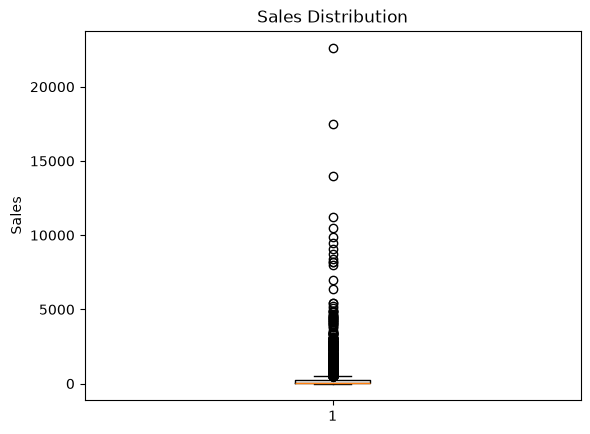

In [27]:
import matplotlib.pyplot as plt

plt.boxplot(df['sales'])
plt.title('Sales Distribution')
plt.ylabel('Sales')
plt.show()

### Sales — Boxplot

- O boxplot confirmou a presença de diversos valores atípicos na coluna `sales`.
- A maior parte das vendas está concentrada em valores relativamente baixos.
- Existem registros com valores significativamente superiores à distribuição principal, chegando a aproximadamente 22,7 mil.
- Esses valores podem influenciar significativamente medidas como a média.
- Os possíveis outliers não serão removidos neste momento; serão investigados para verificar se representam vendas legítimas ou possíveis inconsistências.

In [28]:
df_sales = df.groupby('category')['sales'].max().sort_values(ascending=False)
print(df_sales)

category
Technology         22638.480
Office Supplies     9892.740
Furniture           4416.174
Name: sales, dtype: float64


In [29]:
df_sales_sum = df.groupby('category')['sales'].sum().sort_values(ascending=False)
print(df_sales_sum)

category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64


In [30]:
df_subcategory = df.groupby('sub-category')['sales'].max().sort_values(ascending=False)
print(df_subcategory)

sub-category
Machines       22638.480
Copiers        17499.950
Binders         9892.740
Supplies        8187.650
Phones          4548.810
Chairs          4416.174
Bookcases       4404.900
Tables          4297.644
Accessories     3347.370
Storage         2934.330
Appliances      2625.120
Furnishings     1336.440
Art             1113.024
Labels           786.480
Paper            733.950
Envelopes        604.656
Fasteners         93.360
Name: sales, dtype: float64


In [31]:
df_subcategory_sum = df.groupby('sub-category')['sales'].sum().sort_values(ascending=False)
print(df_subcategory_sum)

sub-category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: sales, dtype: float64


In [32]:
df_profit = df.groupby('sub-category')['profit'].sum().sort_values(ascending=False)
print(df_profit)

sub-category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: profit, dtype: float64


## Análise de Vendas e Lucro por Categoria e Subcategoria
## Sales and Profit Analysis by Category and Subcategory

### 🇧🇷 Observações

- Analisamos as categorias e subcategorias considerando:
  - Valor total de vendas (`sales`)
  - Lucro total (`profit`)
  - Maior venda individual (`max(sales)`)

- **Tecnologia** apresentou o maior valor total de vendas entre as categorias, seguida por **Móveis** e **Materiais de Escritório**.

- Entre as subcategorias, **Phones** apresentou o maior valor acumulado de vendas, seguido por **Chairs**, **Storage**, **Tables** e **Binders**.

- No ranking de lucro, os resultados foram diferentes:
  - **Copiers** apresentou o maior lucro total.
  - **Phones** ficou em segundo lugar.
  - **Accessories** ficou em terceiro.

- Foram identificadas subcategorias com **lucro negativo**:
  - **Tables:** -17.725,48
  - **Bookcases:** -3.472,56
  - **Supplies:** -1.189,10

- **Tables** apresentou um resultado especialmente relevante: está entre as subcategorias com maior volume total de vendas, mas apresentou o **maior prejuízo**.

### 🇧🇷 Próxima investigação

- Relacionar `category` e `sub_category`.
- Comparar vendas totais e lucro dentro de cada categoria.
- Investigar a relação entre **desconto (`discount`) e lucro (`profit`)**, especialmente nas subcategorias com prejuízo.

---

### 🇺🇸 Observations

- We analyzed the categories and sub-categories based on:
  - Total sales value (`sales`)
  - Total profit (`profit`)
  - Highest individual sale (`max(sales)`)

- **Technology** generated the highest total sales among the categories, followed by **Furniture** and **Office Supplies**.

- Among the sub-categories, **Phones** generated the highest total sales, followed by **Chairs**, **Storage**, **Tables**, and **Binders**.

- The profit ranking showed different results:
  - **Copiers** generated the highest total profit.
  - **Phones** ranked second.
  - **Accessories** ranked third.

- Some sub-categories presented **negative profit**:
  - **Tables:** -17,725.48
  - **Bookcases:** -3,472.56
  - **Supplies:** -1,189.10

- **Tables** presented a particularly relevant result: it is among the sub-categories with the highest total sales, but generated the **largest loss**.

### 🇺🇸 Next Investigation

- Relate `category` and `sub_category`.
- Compare total sales and profit within each category.
- Investigate the relationship between **discount (`discount`) and profit (`profit`)**, especially for sub-categories with negative profit.

In [50]:
top5_profit = df.groupby('sub-category')['profit'].sum().sort_values(ascending=False).head(5)

df_top5 = df[df['sub-category'].isin(top5_profit.index)]
print(df_top5[['category', 'sub-category']].drop_duplicates())

            category sub-category
7         Technology       Phones
8    Office Supplies      Binders
12   Office Supplies        Paper
26        Technology  Accessories
335       Technology      Copiers


In [51]:
df_segment_top5 = df.groupby(['segment', 'sub-category'])['profit'].sum().sort_values(ascending=False)

print(df_segment.head())

segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: profit, dtype: float64


In [52]:
df_segment = df.groupby('segment')['profit'].sum().sort_values(ascending=False)
print(df_segment_profit)

segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: profit, dtype: float64


In [58]:
df_top5_profit = df[df['sub-category'].isin(top5_profit.index)]
df_top5_profit.head(5)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.152,6,0.2,90.7152
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,0.2,5.7825
11,12,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.424,4,0.2,68.3568
12,13,CA-2017-114412,2017-04-15,2017-04-20,Standard Class,AA-10480,Andrew Allen,Consumer,United States,Concord,...,28027,South,OFF-PA-10002365,Office Supplies,Paper,Xerox 1967,15.552,3,0.2,5.4432
13,14,CA-2016-161389,2016-12-05,2016-12-10,Standard Class,IM-15070,Irene Maddox,Consumer,United States,Seattle,...,98103,West,OFF-BI-10003656,Office Supplies,Binders,Fellowes PB200 Plastic Comb Binding Machine,407.976,3,0.2,132.5922


In [61]:
df_top5_profit['sales'].describe()

count     4625.000000
mean       200.823209
std        624.060461
min          0.556000
25%         15.712000
50%         45.120000
75%        156.512000
max      17499.950000
Name: sales, dtype: float64

### Sales — Top 5 Subcategorias Mais Lucrativas

#### 🇧🇷 Observações

- A distribuição da variável `sales` apresenta uma diferença significativa entre a média e a mediana.
- A média é de aproximadamente **US$ 200**, enquanto a mediana é de aproximadamente **US$ 45**.
- A grande diferença entre o terceiro quartil (75%) e o valor máximo indica a presença de vendas com valores muito elevados.
- Esses valores extremos podem estar influenciando significativamente a média.
- Portanto, a **mediana pode ser mais representativa do valor típico de uma venda** nessas subcategorias.

#### 🇺🇸 Observations

- The `sales` distribution presents a significant difference between the mean and median.
- The mean is approximately **$200**, while the median is approximately **$45**.
- The large difference between the third quartile (75%) and the maximum value indicates the presence of high-value sales.
- These extreme values may be strongly influencing the mean.
- Therefore, the **median may be more representative of the typical sale value** in these subcategories.

In [72]:
print(df_top5_profit[df_top5_profit['sales'] > 100].head(5))

    row_id        order_id order_date  ship_date       ship_mode customer_id  \
7        8  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
11      12  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
13      14  CA-2016-161389 2016-12-05 2016-12-10  Standard Class    IM-15070   
19      20  CA-2014-143336 2014-08-27 2014-09-01    Second Class    ZD-21925   
35      36  CA-2016-117590 2016-12-08 2016-12-10     First Class    GH-14485   

         customer_name    segment        country           city  ...  \
7      Brosina Hoffman   Consumer  United States    Los Angeles  ...   
11     Brosina Hoffman   Consumer  United States    Los Angeles  ...   
13        Irene Maddox   Consumer  United States        Seattle  ...   
19  Zuschuss Donatelli   Consumer  United States  San Francisco  ...   
35           Gene Hale  Corporate  United States     Richardson  ...   

   postal_code   region       product_id         category sub-category  \
7        900

In [74]:
mediana_copiers = df_top5_profit.groupby('sub-category')['sales'].median().sort_values(ascending=False)
print(mediana_copiers)

sub-category
Copiers        1099.98
Phones          209.97
Accessories     100.00
Paper            26.72
Binders          18.56
Name: sales, dtype: float64


In [75]:
means_copiers = df_top5_profit.groupby('sub-category')['sales'].mean().sort_values(ascending=False)
print(means_copiers)

sub-category
Copiers        2198.941618
Phones          371.211534
Accessories     215.974604
Binders         133.560560
Paper            57.284092
Name: sales, dtype: float64


In [78]:
mean_descont = df_top5_profit.groupby('sub-category')['discount'].mean().sort_values(ascending=False)
print(mean_descont)

sub-category
Binders        0.372292
Copiers        0.161765
Phones         0.154556
Accessories    0.078452
Paper          0.074891
Name: discount, dtype: float64


In [80]:
mean_profit = df_top5_profit.groupby('sub-category')['profit'].mean().sort_values(ascending=False)
print(mean_profit)

sub-category
Copiers        817.909190
Accessories     54.111788
Phones          50.073938
Paper           24.856620
Binders         19.843574
Name: profit, dtype: float64


In [81]:
margin = (
    df_top5_profit.groupby('sub-category')[['profit', 'sales']]
    .sum()
)

margin['profit_margin'] = margin['profit'] / margin['sales']

margin.sort_values('profit_margin', ascending=False)

,profit,sales,profit_margin
sub-category,,,
Paper,34053.5693,78479.206,0.433918
Copiers,55617.8249,149528.030,0.371956
Accessories,41936.6357,167380.318,0.250547
Binders,30221.7633,203412.733,0.148574
Phones,44515.7306,330007.054,0.134893


## Análise de Desconto e Margem de Lucro

### 🇧🇷 Observações

Ao analisar as cinco subcategorias mais lucrativas, observamos diferenças relevantes entre o desconto médio e a margem de lucro.

- **Paper:** desconto médio de 7,49% e margem de lucro de 43,39%.
- **Copiers:** desconto médio de 16,18% e margem de lucro de 37,20%.
- **Accessories:** desconto médio de 7,85% e margem de lucro de 25,05%.
- **Binders:** desconto médio de 37,23% e margem de lucro de 14,86%.
- **Phones:** desconto médio de 15,46% e margem de lucro de 13,49%.

De forma preliminar, observamos que as subcategorias com maiores descontos tendem a apresentar margens de lucro menores. Entretanto, essa relação ainda precisa ser investigada utilizando todas as subcategorias disponíveis no dataset.

Essa observação deu origem à seguinte hipótese:

> **Subcategorias com menor desconto médio tendem a apresentar maior margem de lucro.**

---

### 🇺🇸 Observations

When analyzing the five most profitable sub-categories, we observed relevant differences between average discount and profit margin.

- **Paper:** 7.49% average discount and 43.39% profit margin.
- **Copiers:** 16.18% average discount and 37.20% profit margin.
- **Accessories:** 7.85% average discount and 25.05% profit margin.
- **Binders:** 37.23% average discount and 14.86% profit margin.
- **Phones:** 15.46% average discount and 13.49% profit margin.

As an initial observation, sub-categories with higher average discounts tend to show lower profit margins. However, this relationship still needs to be investigated using all sub-categories available in the dataset.

This observation led to the following hypothesis:

> **Sub-categories with lower average discounts tend to have higher profit margins.**

In [82]:
df_hypothesis = (
    df.groupby('sub-category')[['discount', 'sales', 'profit']]
    .agg({
        'discount': 'mean',
        'sales': 'sum',
        'profit': 'sum'
    })
)

df_hypothesis['profit_margin'] = (
    df_hypothesis['profit'] / df_hypothesis['sales']
)

df_hypothesis

,discount,sales,profit,profit_margin
sub-category,,,,
Accessories,0.078452,167380.3180,41936.6357,0.250547
Appliances,0.166524,107532.1610,18138.0054,0.168675
Art,0.074874,27118.7920,6527.7870,0.240711
Binders,0.372292,203412.7330,30221.7633,0.148574
Bookcases,0.211140,114879.9963,-3472.5560,-0.030228
Chairs,0.170178,328449.1030,26590.1663,0.080957
Copiers,0.161765,149528.0300,55617.8249,0.371956
Envelopes,0.080315,16476.4020,6964.1767,0.422676
Fasteners,0.082028,3024.2800,949.5182,0.313965


In [83]:
df_hypothesis[['discount', 'profit_margin']].corr()

,discount,profit_margin
discount,1.000000,-0.518807
profit_margin,-0.518807,1.000000


In [85]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(
    df_hypothesis['discount'],
    df_hypothesis['profit_margin']
)

print(f"Correlação: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Correlação: -0.5188
P-value: 0.0329


## Teste de Hipótese — Desconto vs. Margem de Lucro

### 🇧🇷 Resultado

A análise apresentou uma correlação de **-0,5188** entre o desconto médio e a margem de lucro, indicando uma relação negativa moderada.

O teste de correlação de Pearson apresentou **p-value = 0,0329**, inferior ao nível de significância de 5% (α = 0,05).

Dessa forma, rejeitamos a hipótese nula e encontramos evidências estatísticas de uma relação linear negativa entre desconto e margem de lucro.

> **Conclusão:** as subcategorias com maiores descontos tendem a apresentar menores margens de lucro.

É importante destacar que correlação não implica causalidade. Portanto, os resultados indicam uma associação entre as variáveis, mas não permitem afirmar que o desconto, isoladamente, seja a causa da redução da margem.

### 🇺🇸 Result

The analysis showed a **-0.5188** correlation between average discount and profit margin, indicating a moderate negative relationship.

The Pearson correlation test resulted in a **p-value of 0.0329**, which is below the 5% significance level (α = 0.05).

Therefore, we reject the null hypothesis and find statistical evidence of a negative linear relationship between average discount and profit margin.

> **Conclusion:** sub-categories with higher discounts tend to have lower profit margins.

It is important to note that correlation does not imply causation. Therefore, the results indicate an association between the variables, but they do not establish that discount alone causes a reduction in profit margin.

In [86]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [87]:
df_time = (
    df.groupby(df['order_date'].dt.year)[['sales', 'profit']]
      .sum()
      .sort_index()
)

df_time

,sales,profit
order_date,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


In [90]:
df_region = (
    df.groupby('region')[['sales', 'profit']]
      .sum()
      .sort_values('profit', ascending=False)
)

df_region

,sales,profit
region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


In [91]:
df_region['profit_margin'] = (
    df_region['profit'] / df_region['sales']
)

df_region.sort_values('profit_margin', ascending=False)

,sales,profit,profit_margin
region,,,
West,725457.8245,108418.4489,0.149448
East,678781.2400,91522.7800,0.134834
South,391721.9050,46749.4303,0.119343
Central,501239.8908,39706.3625,0.079216


In [92]:
df_region_segment = (
    df.groupby(['region', 'segment'])[['sales', 'profit']]
      .sum()
      .sort_values('profit', ascending=False)
)

df_region_segment

sales      profit
region  segment                             
West    Consumer     362880.7730  57450.6040
East    Consumer     350908.1670  41190.9843
West    Corporate    225855.2745  34437.4299
South   Consumer     195580.9710  26913.5728
East    Home Office  127463.7260  26709.2168
        Corporate    200409.3470  23622.5789
Central Corporate    157995.8128  18703.9020
West    Home Office  136721.7770  16530.4150
South   Corporate    121885.9325  15215.2232
Central Home Office   91212.6440  12438.4124
        Consumer     252031.4340   8564.0481
South   Home Office   74255.0015   4620.6343

In [94]:
df_region_category = (
    df.groupby(['region', 'category'])[['sales', 'profit']]
      .sum()
)

df_region_category['profit_margin'] = (
    df_region_category['profit'] /
    df_region_category['sales']
)

df_region_category.sort_values(
    'profit_margin',
    ascending=False
)

sales      profit  profit_margin
region  category                                               
West    Office Supplies  220853.2490  52609.8490       0.238212
East    Office Supplies  205516.0550  41014.5791       0.199569
Central Technology       170416.3120  33697.4320       0.197736
East    Technology       264973.9810  47462.0351       0.179120
West    Technology       251991.8320  44303.6496       0.175814
South   Office Supplies  125651.3130  19986.3928       0.159062
        Technology       148771.9080  19991.8314       0.134379
        Furniture        117298.6840   6771.2061       0.057726
Central Office Supplies  167026.4150   8879.9799       0.053165
West    Furniture        252612.7435  11504.9503       0.045544
East    Furniture        208291.2040   3046.1658       0.014625
Central Furniture        163797.1638  -2871.0494      -0.017528